# Notebook 6: Visualization and Statistical Analysis

**Project:** Evaluating the Functional Correctness and Consistency of AI-Generated Introductory Programming Solutions: Implications for Computing Education

**Author:** Dr. C. V. Krishnaveni

**Institution:** Department of Computer Science, SKR & SKR Government College for Women (Autonomous), Kadapa, Andhra Pradesh, India

---

## Objective

This notebook generates publication-quality visualizations and descriptive statistical summaries from the evaluation results produced in the previous notebooks.

The generated figures and tables support the experimental results presented in the ACM COMPUTE 2026 research paper.

## Workflow

This notebook performs the following tasks:

1. Clone the GitHub repository.
2. Load evaluation results and summary tables.
3. Verify input files.
4. Generate publication-quality figures.
5. Compute descriptive statistics.
6. Save figures and statistical summaries.
7. Prepare outputs for the ACM COMPUTE 2026 paper.

In [ ]:
# ============================================================
# Clone Repository
# ============================================================

!rm -rf AI-Code_Judgement

!git clone https://github.com/vkchennuru/AI-Code_Judgement.git

Cloning into 'AI-Code_Judgement'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (159/159), done.
remote: Total 165 (delta 65), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (165/165), 402.91 KiB | 5.67 MiB/s, done.
Resolving deltas: 100% (65/65), done.


In [ ]:
# ============================================================
# Import Libraries
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path("/content/AI-Code_Judgement")

RESULTS_DIR = PROJECT_ROOT / "results"

FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Results      :", RESULTS_DIR)
print("Figures      :", FIGURES_DIR)

Project Root : /content/AI-Code_Judgement
Results      : /content/AI-Code_Judgement/results
Figures      : /content/AI-Code_Judgement/figures


## Load Evaluation Results and Summary Tables

In [ ]:
# ============================================================
# Load CSV Files
# ============================================================

evaluation_df = pd.read_csv(
    RESULTS_DIR / "evaluation_results.csv"
)

generation_summary = pd.read_csv(
    RESULTS_DIR / "generation_summary.csv"
)

problem_summary = pd.read_csv(
    RESULTS_DIR / "problem_summary.csv"
)

error_summary = pd.read_csv(
    RESULTS_DIR / "error_summary.csv"
)

consistency_summary = pd.read_csv(
    RESULTS_DIR / "consistency_summary.csv"
)

print("Files loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/AI-Code_Judgement/results/generation_summary.csv'

In [ ]:
# ============================================================
# Load CSV Files
# ============================================================

evaluation_df = pd.read_csv(
    RESULTS_DIR / "evaluation_results.csv"
)

overall_summary = pd.read_csv(
    RESULTS_DIR / "overall_summary.csv"
)

problem_summary = pd.read_csv(
    RESULTS_DIR / "problem_summary.csv"
)

error_summary = pd.read_csv(
    RESULTS_DIR / "error_summary.csv"
)

consistency_summary = pd.read_csv(
    RESULTS_DIR / "consistency_summary.csv"
)

execution_statistics = pd.read_csv(
    RESULTS_DIR / "execution_statistics.csv"
)

print("All required files loaded successfully.")

All required files loaded successfully.


## Verify Loaded Data

In [ ]:
# ============================================================
# Verify Data
# ============================================================

print("Evaluation Results    :", evaluation_df.shape)
print("Overall Summary       :", overall_summary.shape)
print("Problem Summary       :", problem_summary.shape)
print("Error Summary         :", error_summary.shape)
print("Consistency Summary   :", consistency_summary.shape)
print("Execution Statistics  :", execution_statistics.shape)

Evaluation Results    : (30, 15)
Overall Summary       : (5, 2)
Problem Summary       : (10, 5)
Error Summary         : (1, 3)
Consistency Summary   : (3, 3)
Execution Statistics  : (4, 2)


In [ ]:
# ============================================================
# Inspect Dataset Structure
# ============================================================

datasets = {
    "overall_summary": overall_summary,
    "problem_summary": problem_summary,
    "error_summary": error_summary,
    "consistency_summary": consistency_summary,
    "execution_statistics": execution_statistics
}

for name, df in datasets.items():
    print("=" * 70)
    print(name.upper())
    print("=" * 70)
    print("Columns:")
    print(df.columns.tolist())
    print("\nFirst few rows:")
    print(df.head())
    print()

OVERALL_SUMMARY
Columns:
['Metric', 'Value']

First few rows:
             Metric  Value
0    Total Programs  30.00
1     Fully Correct  17.00
2            Failed  13.00
3     Pass Rate (%)  56.67
4  Failure Rate (%)  43.33

PROBLEM_SUMMARY
Columns:
['problem_id', 'Total_Generations', 'Correct', 'Failed', 'Pass_Rate(%)']

First few rows:
   problem_id  Total_Generations  Correct  Failed  Pass_Rate(%)
0           1                  3        3       0        100.00
1           2                  3        2       1         66.67
2           3                  3        3       0        100.00
3           4                  3        3       0        100.00
4           5                  3        2       1         66.67

ERROR_SUMMARY
Columns:
['Error Type', 'Count', 'Percentage']

First few rows:
      Error Type  Count  Percentage
0  Runtime Error     13       43.33

CONSISTENCY_SUMMARY
Columns:
['Consistency Type', 'Problems', 'Percentage']

First few rows:
       Consistency Type  Proble

In [ ]:
# ============================================================
# Display Overall Summary
# ============================================================

print(overall_summary)

             Metric  Value
0    Total Programs  30.00
1     Fully Correct  17.00
2            Failed  13.00
3     Pass Rate (%)  56.67
4  Failure Rate (%)  43.33


## Figure 1: Overall Functional Correctness

This figure compares the number of fully correct and failed AI-generated program solutions evaluated in the experiment. It provides an overview of the functional correctness achieved by the generated programs.

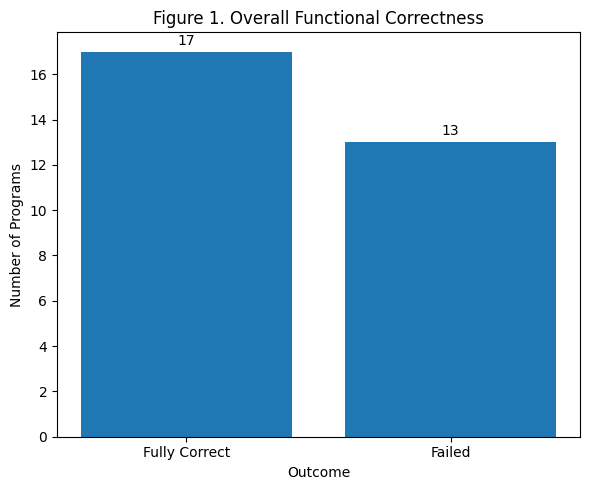

Figure saved successfully.


In [ ]:
# ============================================================
# Figure 1: Overall Functional Correctness
# ============================================================

# Extract required values
correct = overall_summary.loc[
    overall_summary["Metric"] == "Fully Correct",
    "Value"
].values[0]

failed = overall_summary.loc[
    overall_summary["Metric"] == "Failed",
    "Value"
].values[0]

# Create figure
plt.figure(figsize=(6,5))

plt.bar(
    ["Fully Correct", "Failed"],
    [correct, failed]
)

plt.title("Figure 1. Overall Functional Correctness")

plt.xlabel("Outcome")

plt.ylabel("Number of Programs")

# Display values above bars
for i, value in enumerate([correct, failed]):
    plt.text(i, value + 0.3, str(int(value)), ha="center")

plt.tight_layout()

# Save figure
plt.savefig(
    FIGURES_DIR / "figure1_overall_functional_correctness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Interpretation

Out of **30 AI-generated program solutions**, **17 (56.67%)** were functionally correct, while **13 (43.33%)** failed one or more hidden test cases. This result indicates that although AI-generated introductory programming solutions often produce executable and correct code, a substantial proportion of outputs remain unreliable without systematic verification.

## Figure 2: Problem-wise Pass Rate

This figure illustrates the percentage of correct AI-generated solutions for each programming problem. It highlights variations in performance across different introductory programming tasks.

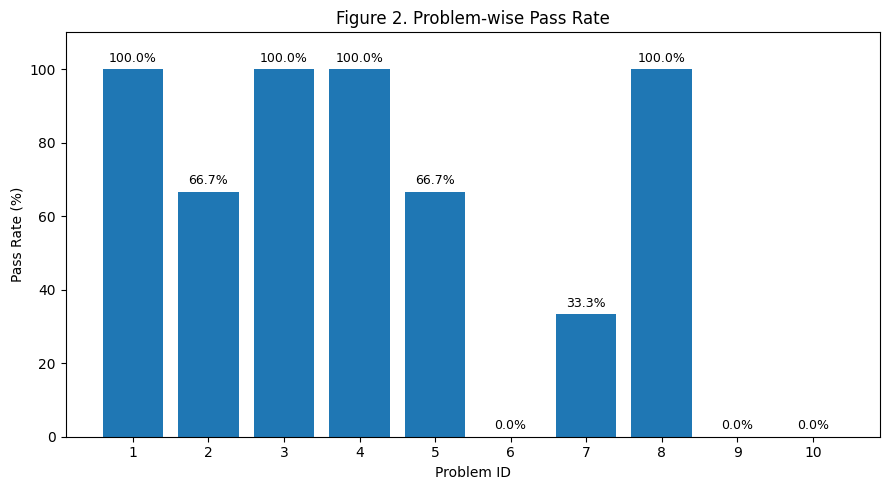

Figure saved successfully.


In [ ]:
# ============================================================
# Figure 2: Problem-wise Pass Rate
# ============================================================

plt.figure(figsize=(9,5))

plt.bar(
    problem_summary["problem_id"].astype(str),
    problem_summary["Pass_Rate(%)"]
)

plt.title("Figure 2. Problem-wise Pass Rate")

plt.xlabel("Problem ID")

plt.ylabel("Pass Rate (%)")

plt.ylim(0, 110)

# Display values above bars
for x, y in zip(problem_summary["problem_id"], problem_summary["Pass_Rate(%)"]):
    plt.text(
        str(x),
        y + 2,
        f"{y:.1f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure2_problemwise_pass_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Interpretation

The pass rate varied across the benchmark problems. Several problems achieved **100% correctness**, indicating that the AI model consistently generated correct solutions for those tasks. However, other problems achieved lower pass rates, demonstrating that functional correctness depends on the characteristics and complexity of the programming problem.

## Figure 3: Error Type Distribution

This figure summarizes the distribution of errors observed during the functional evaluation of AI-generated program solutions. Identifying the predominant error types helps understand the limitations of AI-generated introductory programming code.

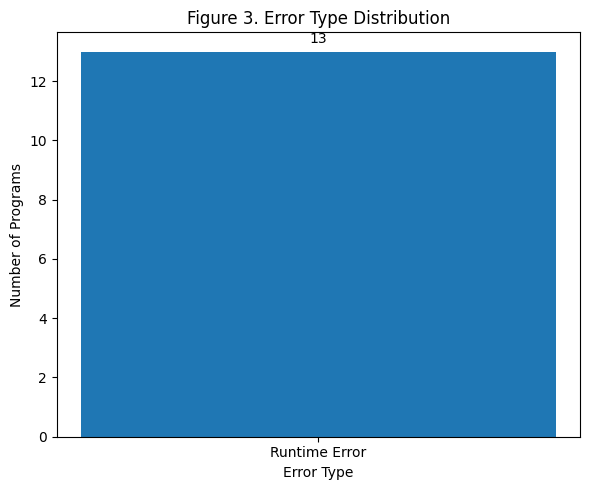

Figure saved successfully.


In [ ]:
# ============================================================
# Figure 3: Error Type Distribution
# ============================================================

plt.figure(figsize=(6,5))

plt.bar(
    error_summary["Error Type"],
    error_summary["Count"]
)

plt.title("Figure 3. Error Type Distribution")

plt.xlabel("Error Type")

plt.ylabel("Number of Programs")

# Display values above the bars
for x, y in zip(error_summary["Error Type"], error_summary["Count"]):
    plt.text(
        x,
        y + 0.3,
        str(int(y)),
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure3_error_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Interpretation

Among the evaluated AI-generated programs, **Runtime Error** was the only observed failure category, accounting for **13 program executions (43.33%)**. This finding suggests that the primary source of incorrect solutions was unsuccessful program execution rather than partial logical correctness, emphasizing the importance of execution-based validation when evaluating AI-generated code.

## Figure 4: Consistency Analysis

This figure presents the consistency of AI-generated program solutions across three independent generations for each benchmark problem. It illustrates the proportion of problems that were consistently correct, partially consistent, or consistently incorrect.

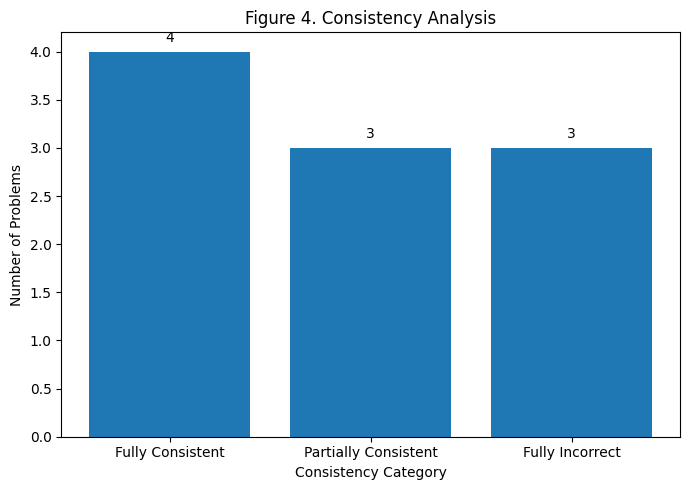

Figure saved successfully.


In [ ]:
# ============================================================
# Figure 4: Consistency Analysis
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(
    consistency_summary["Consistency Type"],
    consistency_summary["Problems"]
)

plt.title("Figure 4. Consistency Analysis")

plt.xlabel("Consistency Category")

plt.ylabel("Number of Problems")

# Display values above bars
for x, y in zip(
    consistency_summary["Consistency Type"],
    consistency_summary["Problems"]
):
    plt.text(
        x,
        y + 0.1,
        str(int(y)),
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure4_consistency_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Interpretation

Among the ten benchmark problems, **4 (40%)** were fully consistent, meaning all three AI-generated solutions were correct. **3 problems (30%)** showed partial consistency, where only some generated solutions passed all hidden test cases. The remaining **3 problems (30%)** were consistently incorrect, indicating that repeated prompting alone does not guarantee reliable program generation. These findings highlight the importance of evaluating both functional correctness and consistency when assessing AI-generated code.

## Figure 5: Execution Time Statistics

This figure summarizes the execution time statistics of the AI-generated program solutions. It provides an overview of the computational efficiency of the generated programs.

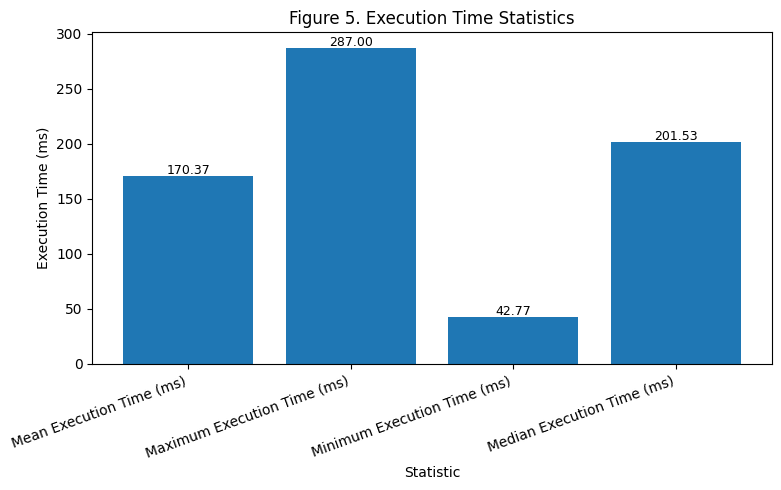

Figure saved successfully.


In [ ]:
# ============================================================
# Figure 5: Execution Time Statistics
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    execution_statistics["Statistic"],
    execution_statistics["Value"]
)

plt.title("Figure 5. Execution Time Statistics")

plt.xlabel("Statistic")

plt.ylabel("Execution Time (ms)")

plt.xticks(rotation=20, ha="right")

# Display values above bars
for x, y in zip(
    execution_statistics["Statistic"],
    execution_statistics["Value"]
):
    plt.text(
        x,
        y + 2,
        f"{y:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure5_execution_statistics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Interpretation

The execution time analysis indicates that all generated programs executed efficiently. The average execution time was **170.37 ms**, while the maximum execution time observed was **287.00 ms**. These results demonstrate that execution failures were primarily due to program correctness rather than computational inefficiency.

## Figure 6: Functional Correctness Distribution

This figure presents the proportion of functionally correct and failed AI-generated program solutions, providing a visual summary of the experimental outcomes.

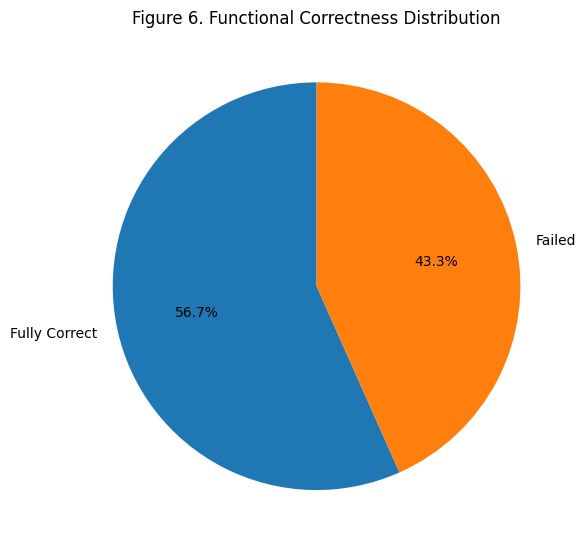

Figure saved successfully.


In [ ]:
# ============================================================
# Figure 6: Functional Correctness Distribution
# ============================================================

labels = ["Fully Correct", "Failed"]

sizes = [17, 13]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Figure 6. Functional Correctness Distribution")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "figure6_functional_correctness_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

### Interpretation

The experiment achieved an overall functional correctness of **56.67%**, while **43.33%** of the generated programs failed at least one hidden test case. Although the AI model produced correct solutions for more than half of the benchmark programs, the results indicate that AI-generated introductory programming solutions require systematic verification before adoption in educational settings.

## Descriptive Statistical Summary

The following statistics summarize the overall experimental results and provide quantitative evidence for the findings reported in the ACM COMPUTE 2026 paper.

In [17]:
# ============================================================
# Descriptive Statistical Summary
# ============================================================

overall_summary

,Metric,Value
0,Total Programs,30.00
1,Fully Correct,17.00
2,Failed,13.00
3,Pass Rate (%),56.67
4,Failure Rate (%),43.33


In [18]:
# ============================================================
# Export Descriptive Statistics
# ============================================================

overall_summary.to_csv(
    RESULTS_DIR / "descriptive_statistics.csv",
    index=False
)

print("descriptive_statistics.csv saved successfully.")

descriptive_statistics.csv saved successfully.


## Reproducibility

This notebook generates publication-quality figures and descriptive statistical summaries using the outputs produced in the previous notebooks.

To reproduce the results:

1. Clone the GitHub repository.
2. Execute Notebooks 1–5 sequentially.
3. Ensure all summary CSV files are available in the `results` directory.
4. Execute this notebook from beginning to end.

Outputs generated by this notebook include:

- Publication-quality figures (300 dpi)
- `descriptive_statistics.csv`

These outputs are intended for direct use in the ACM COMPUTE 2026 paper and support complete experimental reproducibility.

## Conclusion

This notebook transformed the experimental results into publication-quality visualizations and descriptive statistical summaries. These figures and tables provide clear evidence supporting the functional correctness, consistency, reliability, and execution characteristics of AI-generated introductory programming solutions.

In [19]:
print("=" * 70)
print("Notebook 6 Completed Successfully")
print("=" * 70)

Notebook 6 Completed Successfully
